In [268]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [269]:
df_train = pd.read_csv('../data/train.csv')

C:\Users\yizhe\AppData\Local\Temp\ipykernel_4424\788172147.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('../data/train.csv')


In [270]:
df_train.head()

,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,...,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,...,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,...,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,...,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,...,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


In [271]:
df_train.dtypes.value_counts()

int64      32
float64    25
object     20
Name: count, dtype: int64

In [272]:
df_train.drop(columns=["id"], inplace=True) # drop id column since it is not useful for modeling
num_col = df_train.select_dtypes(include=['int64']).columns
float_col = df_train.select_dtypes(include=['float64']).columns
cat_col = df_train.select_dtypes(include=['object']).columns

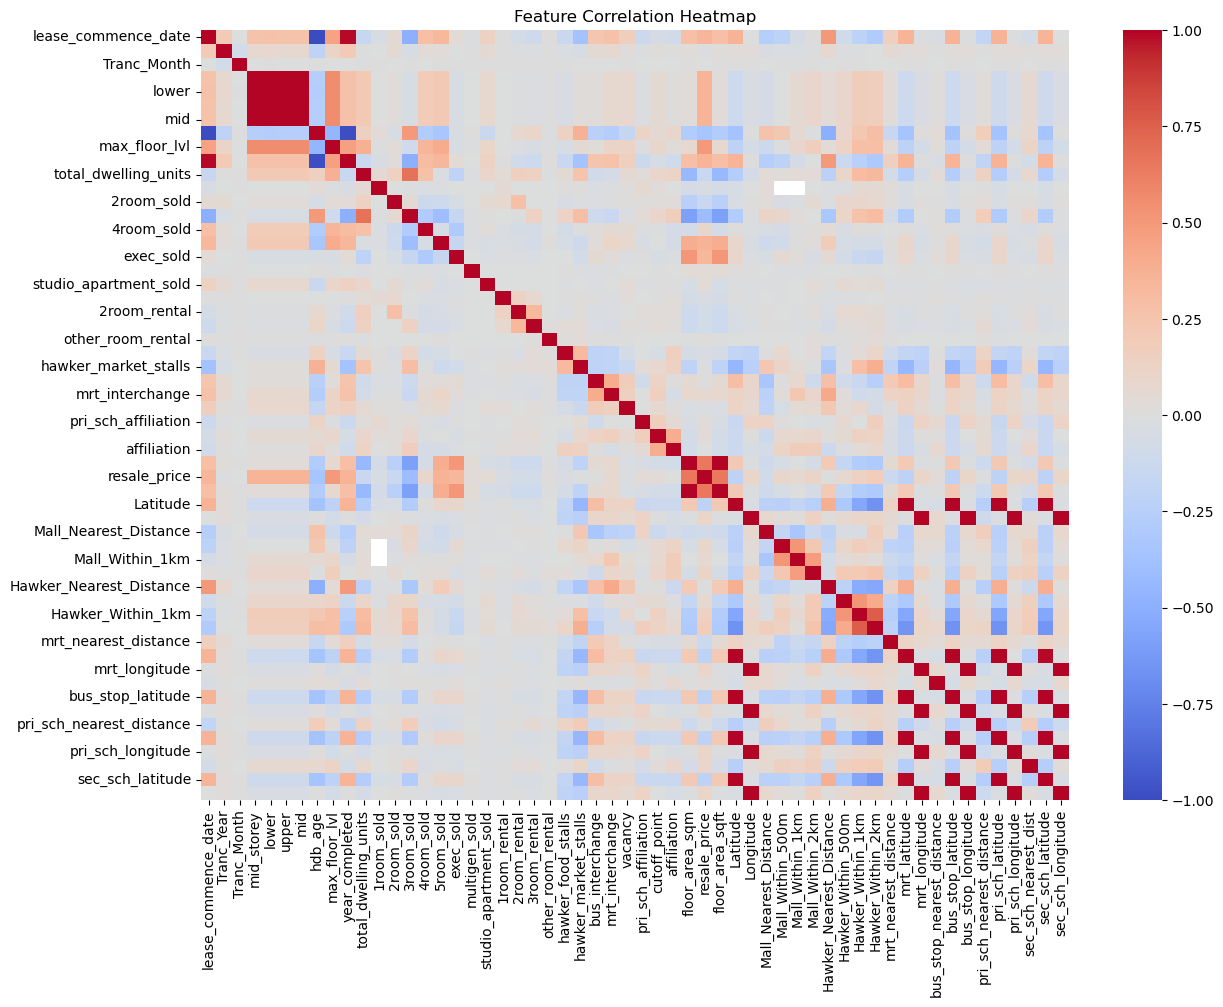

In [273]:
num_features = num_col.tolist() + float_col.tolist()

corr = df_train[num_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [274]:
corr = df_train[num_features].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
high_corr_pairs.head(50)

lease_commence_date   hdb_age               1.000000
mid_storey            mid                   1.000000
floor_area_sqm        floor_area_sqft       1.000000
Longitude             bus_stop_longitude    0.999937
Latitude              bus_stop_latitude     0.999819
lower                 mid                   0.999423
mid_storey            lower                 0.999423
upper                 mid                   0.999421
mid_storey            upper                 0.999421
Longitude             pri_sch_longitude     0.999227
bus_stop_longitude    pri_sch_longitude     0.999172
Longitude             sec_sch_longitude     0.998698
bus_stop_longitude    sec_sch_longitude     0.998644
pri_sch_longitude     sec_sch_longitude     0.998426
lower                 upper                 0.997688
Latitude              pri_sch_latitude      0.997589
bus_stop_latitude     pri_sch_latitude      0.997443
Longitude             mrt_longitude         0.996590
mrt_longitude         bus_stop_longitude    0.

In [275]:
check_duplicate_attributes = [
    ("lease_commence_date", "hdb_age"),
    ("mid_storey", "mid"),
    ("floor_area_sqm", "floor_area_sqft")
]

for i, j in check_duplicate_attributes:
    same = np.isclose(df_train[i], df_train[j], equal_nan=True).all()
    print(f"{i} vs {j}: {same}")

lease_commence_date vs hdb_age: False
mid_storey vs mid: True
floor_area_sqm vs floor_area_sqft: False


In [276]:
#drop the duplicate attributes
df_train.drop(['mid_storey'], axis=1, inplace=True)
df_train.drop(['floor_area_sqft'], axis=1, inplace=True)
df_train.drop(['lease_commence_date'], axis=1, inplace=True)

num_col = df_train.select_dtypes(include=['int64']).columns
float_col = df_train.select_dtypes(include=['float64']).columns
cat_col = df_train.select_dtypes(include=['object']).columns

Clean num_col first:

1. Check negative values
2. check logic violations

In [277]:
df_train[num_col].isnull().sum().sort_values(ascending=False)

Tranc_Year               0
multigen_sold            0
cutoff_point             0
pri_sch_affiliation      0
vacancy                  0
mrt_interchange          0
bus_interchange          0
hawker_market_stalls     0
hawker_food_stalls       0
other_room_rental        0
3room_rental             0
2room_rental             0
1room_rental             0
studio_apartment_sold    0
exec_sold                0
Tranc_Month              0
5room_sold               0
4room_sold               0
3room_sold               0
2room_sold               0
1room_sold               0
total_dwelling_units     0
year_completed           0
max_floor_lvl            0
hdb_age                  0
mid                      0
upper                    0
lower                    0
affiliation              0
dtype: int64

In [278]:
df_train[num_col].head()

,Tranc_Year,Tranc_Month,lower,upper,mid,hdb_age,max_floor_lvl,year_completed,total_dwelling_units,1room_sold,...,3room_rental,other_room_rental,hawker_food_stalls,hawker_market_stalls,bus_interchange,mrt_interchange,vacancy,pri_sch_affiliation,cutoff_point,affiliation
0,2016,5,10,12,11,15,25,2005,142,0,...,0,0,84,60,0,0,78,1,224,0
1,2012,7,7,9,8,34,9,1987,112,0,...,0,0,80,77,1,1,45,1,232,0
2,2013,7,13,15,14,24,16,1996,90,0,...,0,0,84,95,1,0,39,0,188,0
3,2012,4,1,5,3,29,11,1990,75,0,...,0,0,32,86,1,1,20,1,253,1
4,2017,12,1,3,2,34,4,1987,48,0,...,0,0,45,0,0,0,74,0,208,0


In [279]:
(df_train[num_col] < 0).sum().sort_values(ascending=False) # check for negative values in numeric columns

Tranc_Year               0
multigen_sold            0
cutoff_point             0
pri_sch_affiliation      0
vacancy                  0
mrt_interchange          0
bus_interchange          0
hawker_market_stalls     0
hawker_food_stalls       0
other_room_rental        0
3room_rental             0
2room_rental             0
1room_rental             0
studio_apartment_sold    0
exec_sold                0
Tranc_Month              0
5room_sold               0
4room_sold               0
3room_sold               0
2room_sold               0
1room_sold               0
total_dwelling_units     0
year_completed           0
max_floor_lvl            0
hdb_age                  0
mid                      0
upper                    0
lower                    0
affiliation              0
dtype: int64

No negative values

Identify bool from generic attributes

In [280]:
bool_like_cols = [
    col for col in num_col
    if df_train[col].dropna().isin([0, 1]).all()
]

bool_like_cols

['bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']

Clean float col

In [281]:
df_train[float_col].isnull().sum()

floor_area_sqm                   0
resale_price                     0
Latitude                         0
Longitude                        0
Mall_Nearest_Distance          829
Mall_Within_500m             92789
Mall_Within_1km              25426
Mall_Within_2km               1940
Hawker_Nearest_Distance          0
Hawker_Within_500m           97390
Hawker_Within_1km            60868
Hawker_Within_2km            29202
mrt_nearest_distance             0
mrt_latitude                     0
mrt_longitude                    0
bus_stop_nearest_distance        0
bus_stop_latitude                0
bus_stop_longitude               0
pri_sch_nearest_distance         0
pri_sch_latitude                 0
pri_sch_longitude                0
sec_sch_nearest_dist             0
sec_sch_latitude                 0
sec_sch_longitude                0
dtype: int64

In [282]:
print(float_col)

Index(['floor_area_sqm', 'resale_price', 'Latitude', 'Longitude',
       'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km',
       'Mall_Within_2km', 'Hawker_Nearest_Distance', 'Hawker_Within_500m',
       'Hawker_Within_1km', 'Hawker_Within_2km', 'mrt_nearest_distance',
       'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance',
       'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance',
       'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist',
       'sec_sch_latitude', 'sec_sch_longitude'],
      dtype='object')


In [283]:
(df_train[float_col] < 0).sum().sort_values(ascending=False) # check for negative values in float columns

floor_area_sqm               0
resale_price                 0
sec_sch_latitude             0
sec_sch_nearest_dist         0
pri_sch_longitude            0
pri_sch_latitude             0
pri_sch_nearest_distance     0
bus_stop_longitude           0
bus_stop_latitude            0
bus_stop_nearest_distance    0
mrt_longitude                0
mrt_latitude                 0
mrt_nearest_distance         0
Hawker_Within_2km            0
Hawker_Within_1km            0
Hawker_Within_500m           0
Hawker_Nearest_Distance      0
Mall_Within_2km              0
Mall_Within_1km              0
Mall_Within_500m             0
Mall_Nearest_Distance        0
Longitude                    0
Latitude                     0
sec_sch_longitude            0
dtype: int64

In [284]:
bool_like_float_cols = [
    col for col in float_col
    if df_train[col].isin((0.0, 1.0)).all()
]

bool_like_float_cols

[]

In [ ]:
#check if floats are actually integers
int_cols = [
    col for col in float_col
    if df_train[col].dropna().apply(lambda x: x.is_integer()).all()
]
int_cols

# float_to_int_cols = [ col for col in float_col
#                      if np.all(np.isclose(df_train[col] % 1, 0, equal_nan=True)) ]

# float_to_int_cols

['Mall_Within_500m',
 'Mall_Within_1km',
 'Mall_Within_2km',
 'Hawker_Within_500m',
 'Hawker_Within_1km',
 'Hawker_Within_2km']

In [229]:
print(df_train["Mall_Within_500m"])

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
150629    NaN
150630    1.0
150631    NaN
150632    NaN
150633    1.0
Name: Mall_Within_500m, Length: 150634, dtype: float64


Feature eng within num col only:

time: 
tranc_month_year -> 'Tranc_Year'+ 'Tranc_Month'
compare for idk.... inflation??

Apartment further details:


resale data:
popular hdb sold->  '1room_sold' + '2room_sold' + '3room_sold' + 
       '4room_sold' + '5room_sold' + 'exec_sold' + 'multigen_sold' +
       'studio_apartment_sold'
       
popular rental spot -> '1room_rental' + '2room_rental' + '3room_rental' +
       'other_room_rental'

school prestige:
'vacancy', 'pri_sch_affiliation',
       'cutoff_point', 'affiliation'

popular primary school -> 1/vacancy

secondary_school_prestige -> cutoff_point 




TODO: fill missing relavent values using high corr 0.9x